In [1]:
import pandas as pd

from src.VideoIngestor import augment_dataset
from pathlib import Path
from utils.plot import plotTrainResults

from utils.constants import VALIDATION_CSV
from utils.constants import BASELINE_CONFIG
baseline_train = BASELINE_CONFIG


In [2]:
df_p1 = pd.read_csv(Path("data/phase1_train.csv"))

histology_freqs = df_p1["histology"].value_counts()

print(histology_freqs)
print(sum(histology_freqs))

histology
Adenoma                     1515
Sessile_serrated_adenoma     671
Hyperplastic                 319
Adenocarcinoma               100
Name: count, dtype: int64
2605


In [3]:
augment_dataset(r"utils/models/CVC_ClinicDB_yolov8m.pt")

Max candidates per histology: {'Adenoma': 1, 'Sessile_serrated_adenoma': 3, 'Hyperplastic': 5, 'Adenocarcinoma': 16}
Histology augmentation summary:
               histology  current_samples  max_added_per_sample  max_added_samples  estimated_final_samples
                 Adenoma             1515                     1               1515                     3030
Sessile_serrated_adenoma              671                     3               2013                     2684
            Hyperplastic              319                     5               1595                     1914
          Adenocarcinoma              100                    16               1600                     1700
Estimated totals: current_samples=2605, max_added_samples=6723, estimated_final_samples=9328


Reintentando videos: 100%|██████████| 4/4 [00:29<00:00,  7.49s/video, pendientes=0 fallidos=4 anadidas[Adenoma:1326 SSA:1779 Hyperplastic:1313 Adenocarcinoma:845]]


{'videos_processed_first_pass': 237,
 'videos_recovered_second_pass': 0,
 'videos_still_failed': 4,
 'videos_done': 421,
 'videos_pending': 0,
 'ingestion_complete': False,
 'rows_output': 7868,
 'output_csv_path': 'data\\phase2\\phase2_trainv2.csv',
 'state_json_path': 'data\\phase2\\phase2_trainv2.json'}

In [4]:
phase2_csv_dir = Path('data/phase2/phase2_trainv2.csv')

histology_freqs = pd.read_csv(phase2_csv_dir)["histology"].value_counts()

print(histology_freqs)

histology
Adenoma                     2841
Sessile_serrated_adenoma    2450
Hyperplastic                1632
Adenocarcinoma               945
Name: count, dtype: int64


Hardware assigned for tensor computations: cuda
Training metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\phase2\phase2_trainv2.csv
Validation metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\validation.csv
Train class distribution:
histology
Adenoma                     2841
Sessile_serrated_adenoma    2450
Hyperplastic                1632
Adenocarcinoma               945

Validation class distribution:
histology
Adenoma                     379
Sessile_serrated_adenoma    168
Hyperplastic                 80
Adenocarcinoma               20
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase2


Training Progress:  19%|█▉        | 38/200 [2:21:01<10:01:13, 222.67s/epoch, Stage=full_network, Train Loss=0.8065, Val Loss=1.0546, Val Macro F1=0.4486, Val Score=0.5815, Best Epoch=27, LR=1.2e-07/1.3e-05]       
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:930: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` f


Early stopping triggered after 12 epochs without improving the validation score.

Optimization sequence completed. Selected checkpoint macro-F1: 0.4548 with validation loss 1.0446 and validation score 0.5695 at epoch 27.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase2'.


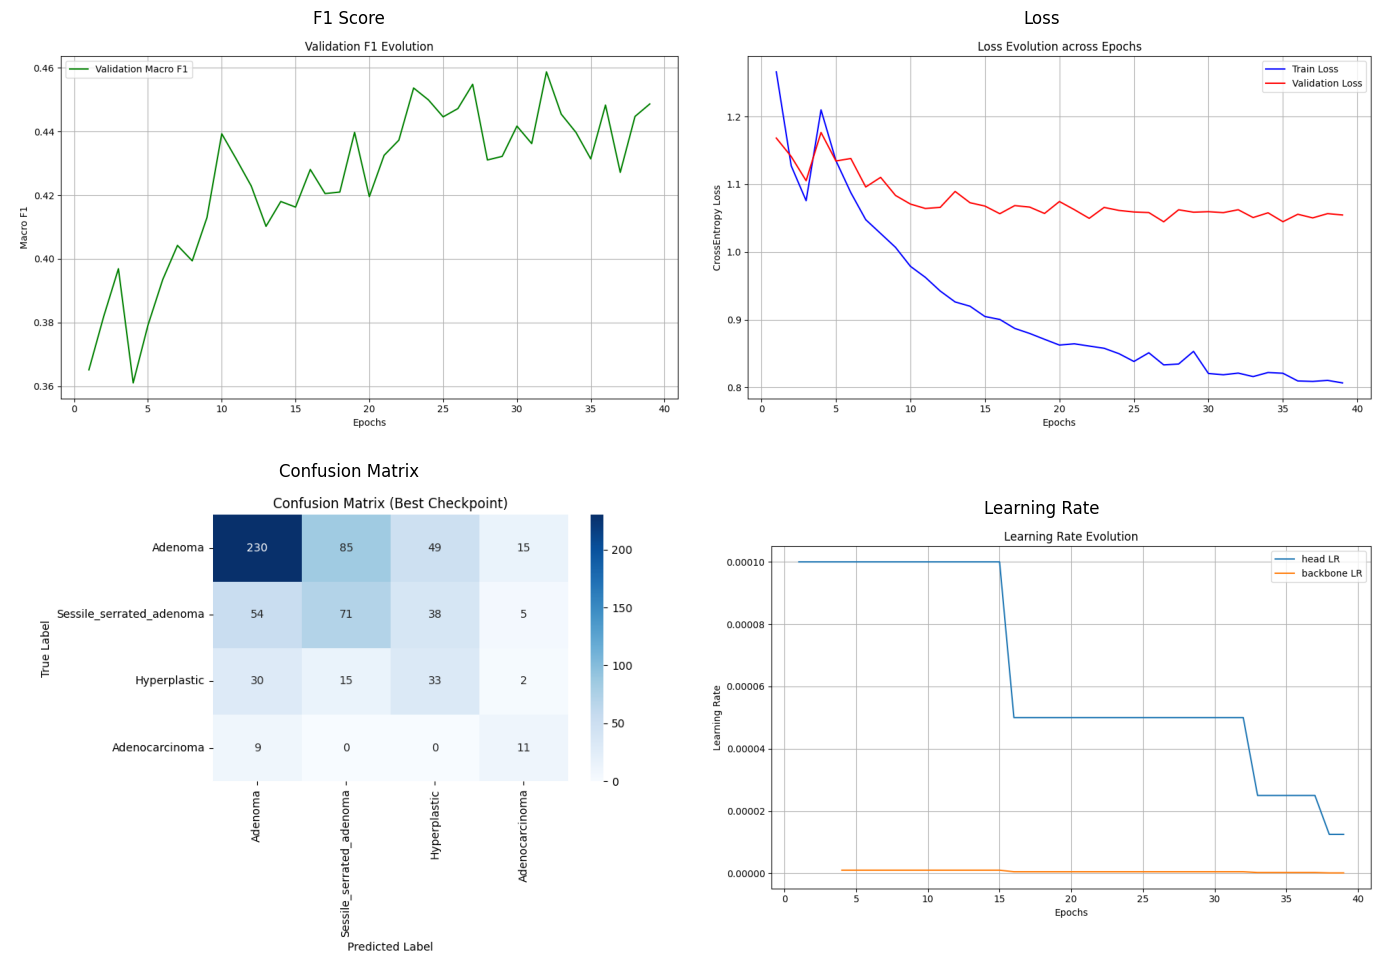

=== GLOBAL METRICS ===
Accuracy:          0.5332
Balanced Accuracy: 0.4980
Macro F1:          0.4548
Weighted F1:       0.5462

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.7121    0.6069    0.6553       379
Sessile_serrated_adenoma     0.4152    0.4226    0.4189       168
            Hyperplastic     0.2750    0.4125    0.3300        80
          Adenocarcinoma     0.3333    0.5500    0.4151        20

                accuracy                         0.5332       647
               macro avg     0.4339    0.4980    0.4548       647
            weighted avg     0.5692    0.5332    0.5462       647



In [5]:
baseline_train.random_state = 42

phase2_img_dir = Path("phase2/framesv2")
phase2_csv_dir = Path("phase2/phase2_trainv2.csv")
phase2_validation_csv_dir = VALIDATION_CSV
phase2_validation_img_dir = Path("unified_images")
phase2_dir = Path('phase2')

plotTrainResults(
    train_csv_dir=phase2_csv_dir,
    validation_csv_dir=phase2_validation_csv_dir,
    train_img_dir=phase2_img_dir,
    validation_img_dir=phase2_validation_img_dir,
    results_dir=phase2_dir,
    train=baseline_train,
)